# Visual EDA — NLBSE’23 Code Comment Classification

Notebook chuyên về **biểu đồ EDA** cho ba bộ dữ liệu gốc `java.csv`, `pharo.csv`, `python.csv` và đối chiếu với dữ liệu Python đã preprocessing.

Mỗi phần được thiết kế để có thể dùng trực tiếp trong báo cáo hoặc slide. File processed không được tính như một dataset độc lập vì nó được sinh từ `python.csv`.

In [1]:
from pathlib import Path
from collections import Counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {'Java': '#2563EB', 'Pharo': '#8B5CF6', 'Python': '#F59E0B'}
DATA_DIR = next((p for p in [Path('data'), Path('../data')] if p.exists()), Path('data'))
FILES = {'Java': 'java.csv', 'Pharo': 'pharo.csv', 'Python': 'python.csv'}
raw = {lang: pd.read_csv(DATA_DIR / filename) for lang, filename in FILES.items()}

def add_value_labels(ax, fmt='{:.0f}', horizontal=False, fontsize=9):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3, fontsize=fontsize)

def finish(ax, title, xlabel='', ylabel=''):
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.spines[['top', 'right']].set_visible(False)

print('Loaded:', {lang: df.shape for lang, df in raw.items()})

Loaded: {'Java': (16926, 6), 'Pharo': (12355, 6), 'Python': (12775, 6)}


## 1. Quy mô và cấu trúc dataset

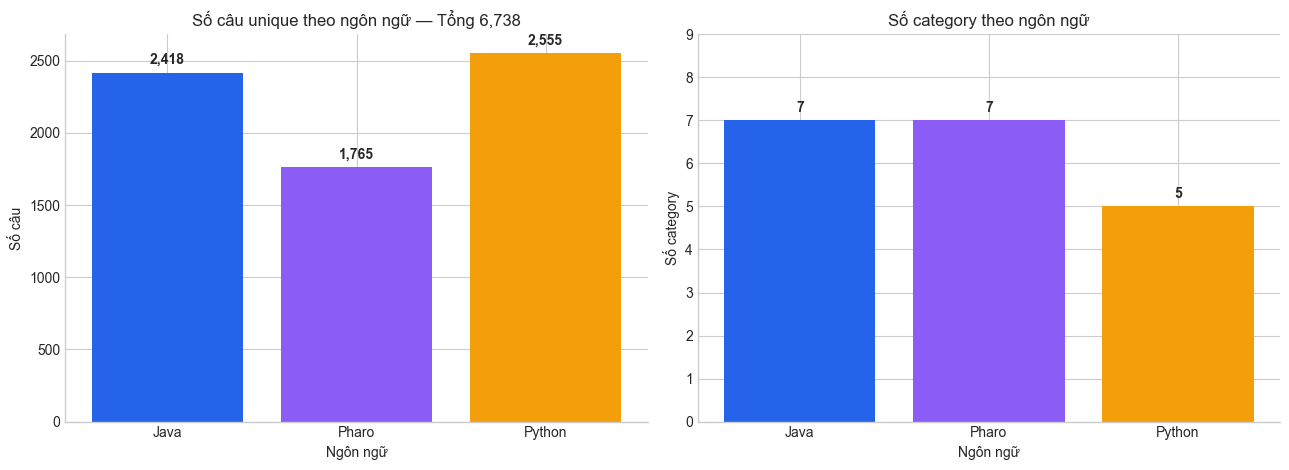

In [2]:
sample_counts = pd.Series({lang: df.comment_sentence_id.nunique() for lang, df in raw.items()})
category_counts = pd.Series({lang: df.category.nunique() for lang, df in raw.items()})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
bars = axes[0].bar(sample_counts.index, sample_counts.values, color=[COLORS[x] for x in sample_counts.index])
axes[0].bar_label(bars, labels=[f'{x:,}' for x in sample_counts.values], padding=4, fontweight='bold')
finish(axes[0], f'Số câu unique theo ngôn ngữ — Tổng {sample_counts.sum():,}', 'Ngôn ngữ', 'Số câu')

bars = axes[1].bar(category_counts.index, category_counts.values, color=[COLORS[x] for x in category_counts.index])
axes[1].bar_label(bars, padding=4, fontweight='bold')
finish(axes[1], 'Số category theo ngôn ngữ', 'Ngôn ngữ', 'Số category')
axes[1].set_ylim(0, category_counts.max() + 2)
plt.tight_layout()
plt.show()

> **Insight:** Java 2.418 + Pharo 1.765 + Python 2.555 = 6.738 câu công bố. Java và Pharo có 7 nhãn, Python có 5 nhãn.

## 2. Data quality overview

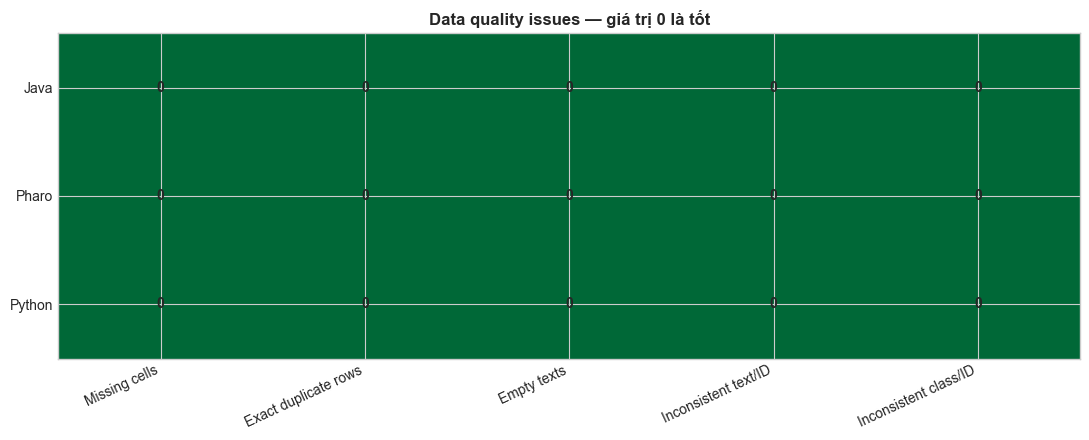

In [3]:
quality = []
for lang, df in raw.items():
    one = df.drop_duplicates('comment_sentence_id')
    quality.append({
        'Language': lang,
        'Missing cells': int(df.isna().sum().sum()),
        'Exact duplicate rows': int(df.duplicated().sum()),
        'Empty texts': int(one.comment_sentence.astype(str).str.strip().eq('').sum()),
        'Inconsistent text/ID': int(df.groupby('comment_sentence_id').comment_sentence.nunique().gt(1).sum()),
        'Inconsistent class/ID': int(df.groupby('comment_sentence_id')['class'].nunique().gt(1).sum()),
    })
quality = pd.DataFrame(quality).set_index('Language')

fig, ax = plt.subplots(figsize=(11, 4.5))
image = ax.imshow(quality.to_numpy(), cmap='RdYlGn_r', aspect='auto', vmin=0)
ax.set_xticks(range(quality.shape[1]), quality.columns, rotation=25, ha='right')
ax.set_yticks(range(quality.shape[0]), quality.index)
for i in range(quality.shape[0]):
    for j in range(quality.shape[1]):
        ax.text(j, i, str(quality.iloc[i, j]), ha='center', va='center', fontweight='bold')
ax.set_title('Data quality issues — giá trị 0 là tốt', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Phân bố nhãn và imbalance

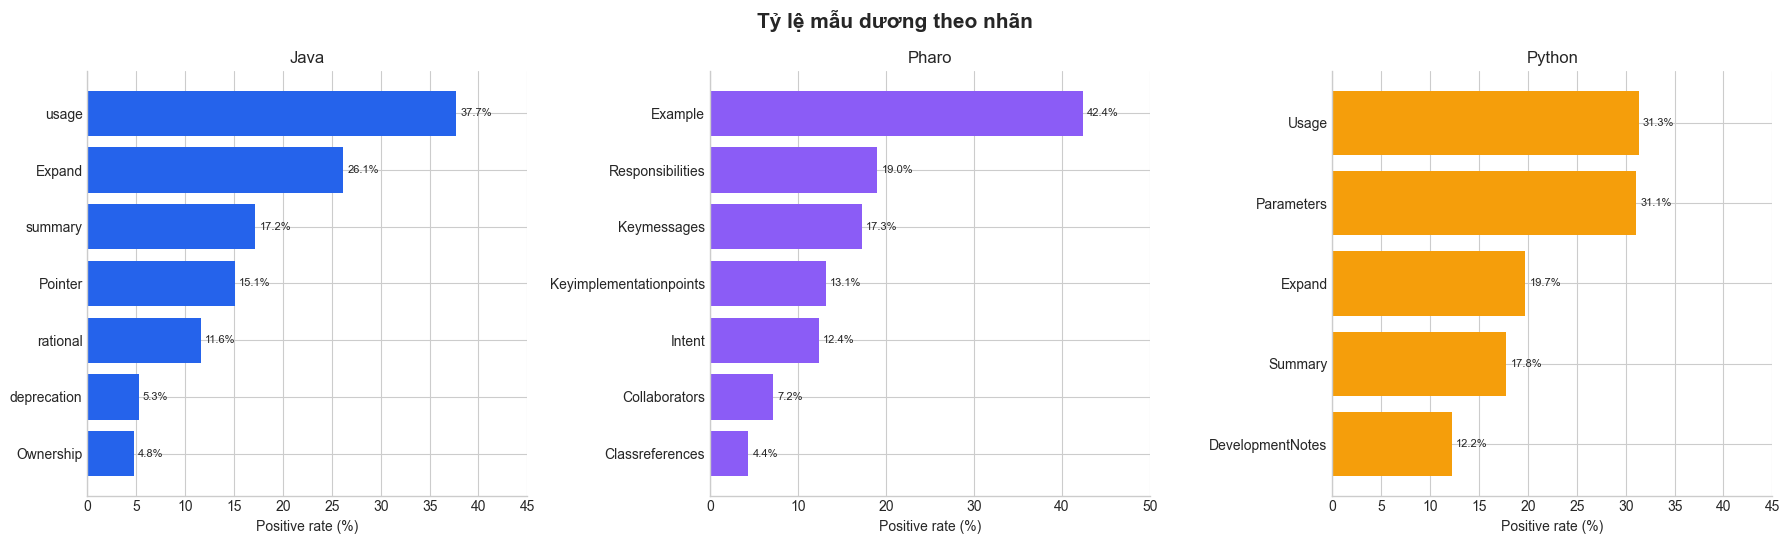

In [4]:
wide = {
    lang: df.pivot(index='comment_sentence_id', columns='category', values='instance_type').astype('int8').sort_index(axis=1)
    for lang, df in raw.items()
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (lang, y) in zip(axes, wide.items()):
    prevalence = (100 * y.mean()).sort_values()
    bars = ax.barh(prevalence.index, prevalence.values, color=COLORS[lang])
    ax.bar_label(bars, labels=[f'{x:.1f}%' for x in prevalence.values], padding=3, fontsize=8)
    finish(ax, lang, 'Positive rate (%)', '')
    ax.set_xlim(0, max(45, prevalence.max() * 1.18))
fig.suptitle('Tỷ lệ mẫu dương theo nhãn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

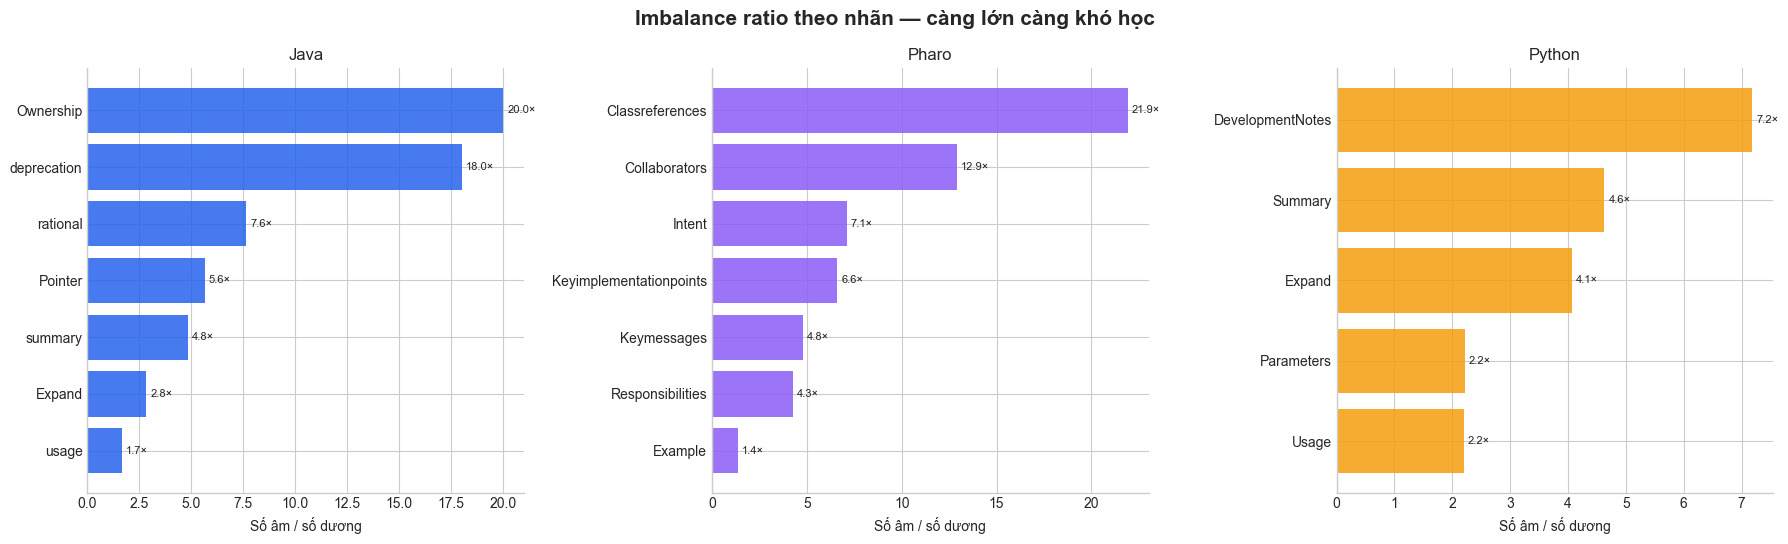

In [5]:
imbalance_records = []
for lang, y in wide.items():
    for label in y.columns:
        positive = y[label].sum()
        imbalance_records.append({
            'Language': lang, 'Label': label,
            'Negative / Positive': (len(y) - positive) / positive,
        })
imbalance = pd.DataFrame(imbalance_records)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, lang in zip(axes, COLORS):
    part = imbalance.query('Language == @lang').sort_values('Negative / Positive')
    bars = ax.barh(part.Label, part['Negative / Positive'], color=COLORS[lang], alpha=.85)
    ax.bar_label(bars, labels=[f'{x:.1f}×' for x in part['Negative / Positive']], padding=3, fontsize=8)
    finish(ax, lang, 'Số âm / số dương', '')
fig.suptitle('Imbalance ratio theo nhãn — càng lớn càng khó học', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Label cardinality và tổ hợp nhãn

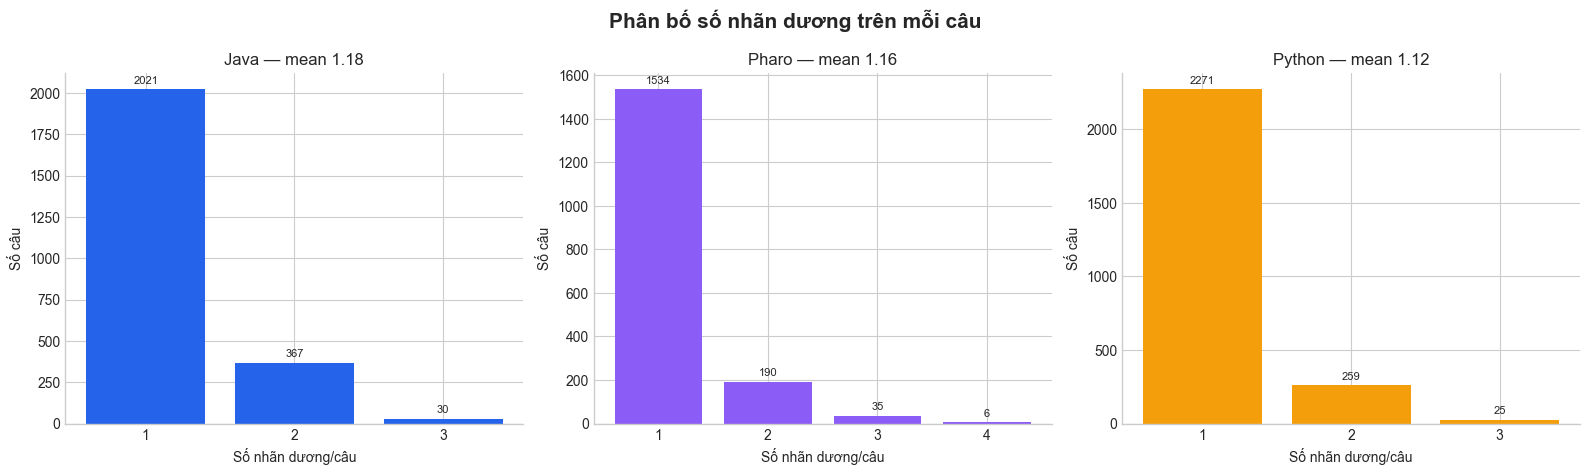

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (lang, y) in zip(axes, wide.items()):
    dist = y.sum(axis=1).value_counts().sort_index()
    bars = ax.bar(dist.index.astype(str), dist.values, color=COLORS[lang])
    ax.bar_label(bars, fontsize=8, padding=3)
    cardinality = y.sum(axis=1).mean()
    finish(ax, f'{lang} — mean {cardinality:.2f}', 'Số nhãn dương/câu', 'Số câu')
fig.suptitle('Phân bố số nhãn dương trên mỗi câu', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

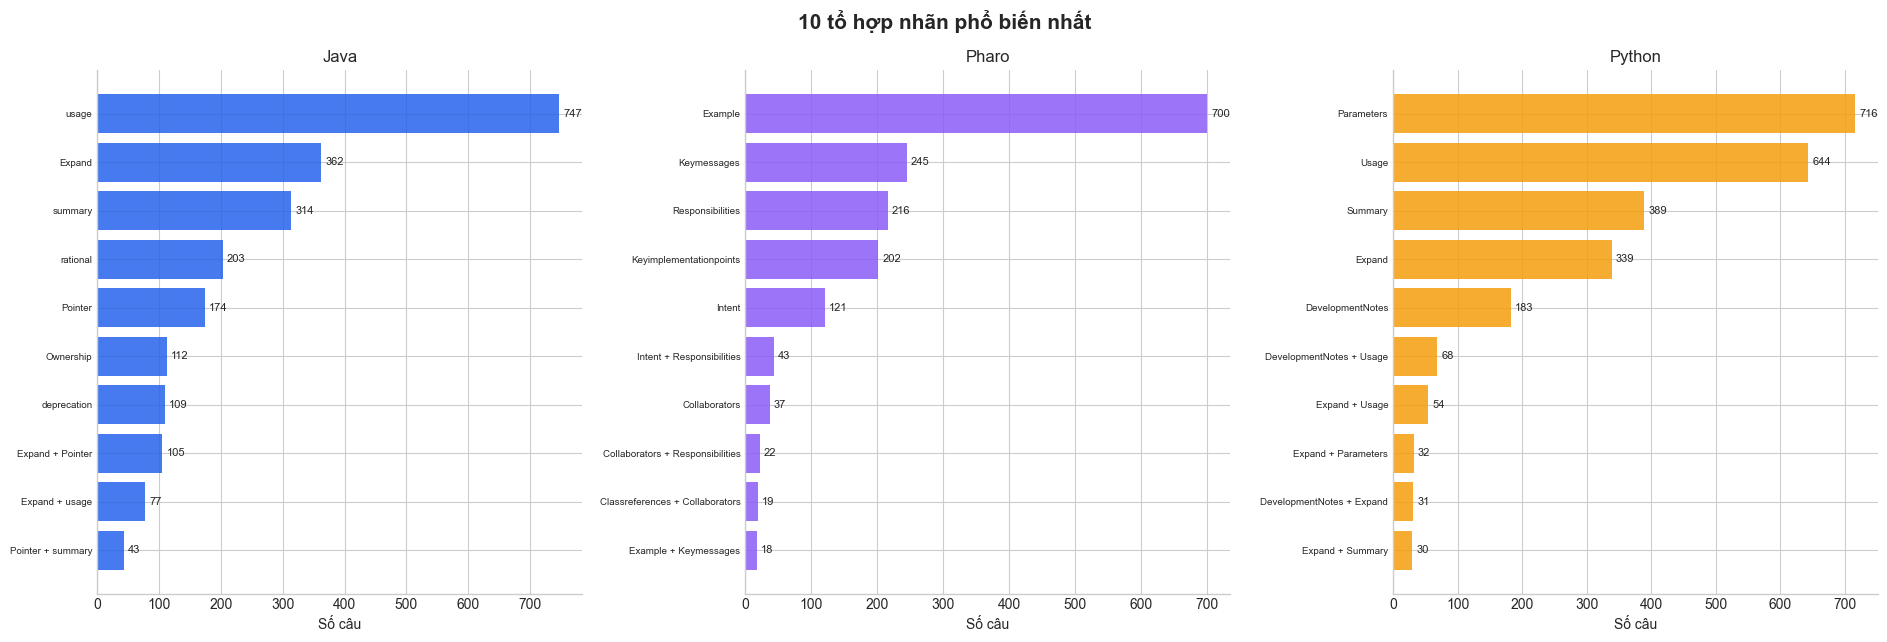

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
for ax, (lang, y) in zip(axes, wide.items()):
    combos = y.apply(lambda row: ' + '.join(row.index[row.eq(1)]) or '(none)', axis=1)
    top = combos.value_counts().head(10).sort_values()
    bars = ax.barh(top.index, top.values, color=COLORS[lang], alpha=.85)
    ax.bar_label(bars, fontsize=8, padding=3)
    finish(ax, lang, 'Số câu', '')
    ax.tick_params(axis='y', labelsize=7)
fig.suptitle('10 tổ hợp nhãn phổ biến nhất', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Label co-occurrence

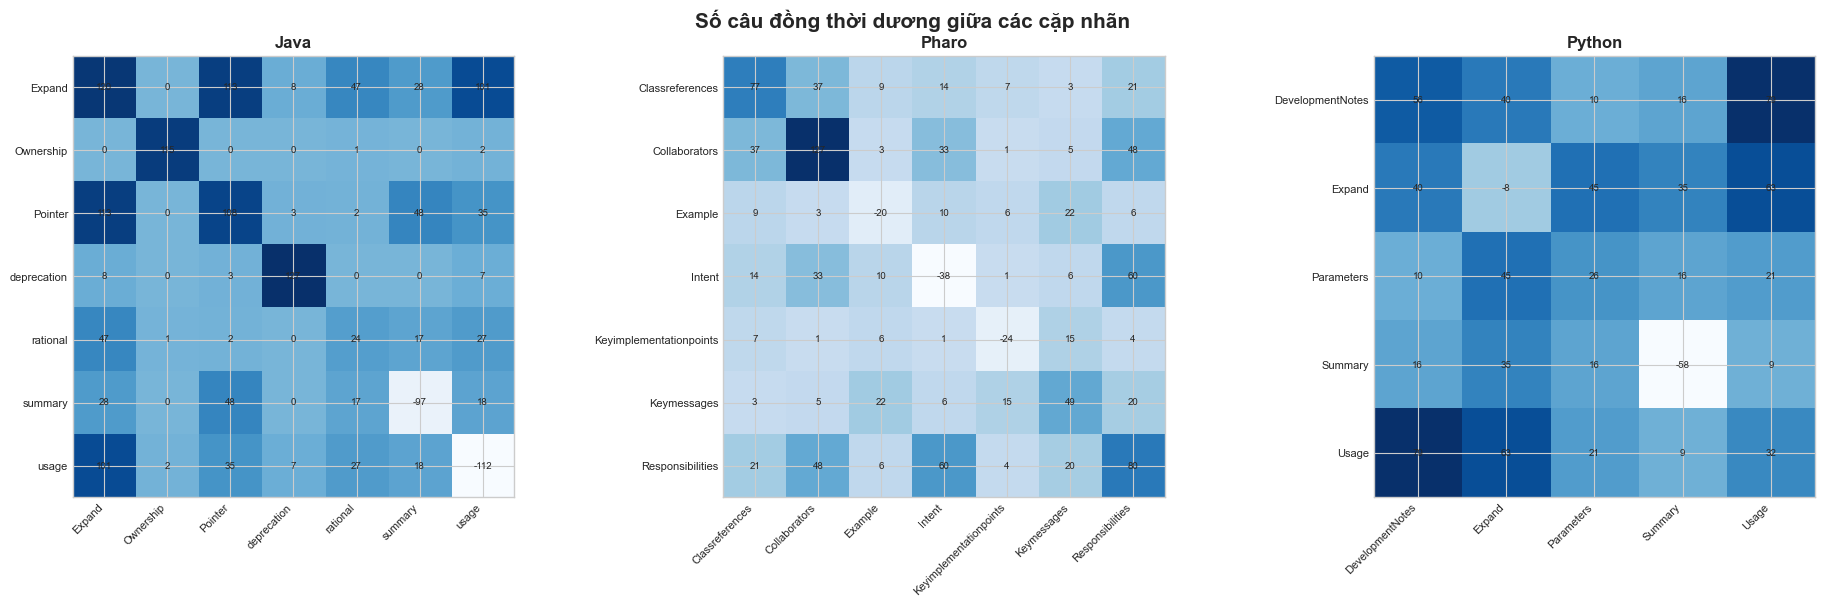

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, (lang, y) in zip(axes, wide.items()):
    cooc = y.T.dot(y).astype(int)
    ax.imshow(cooc, cmap='Blues')
    ax.set_xticks(range(len(cooc)), cooc.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(cooc)), cooc.index, fontsize=8)
    for i in range(len(cooc)):
        for j in range(len(cooc)):
            ax.text(j, i, f'{cooc.iloc[i, j]}', ha='center', va='center', fontsize=7)
    ax.set_title(lang, fontweight='bold')
fig.suptitle('Số câu đồng thời dương giữa các cặp nhãn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Độ dài và đặc điểm text

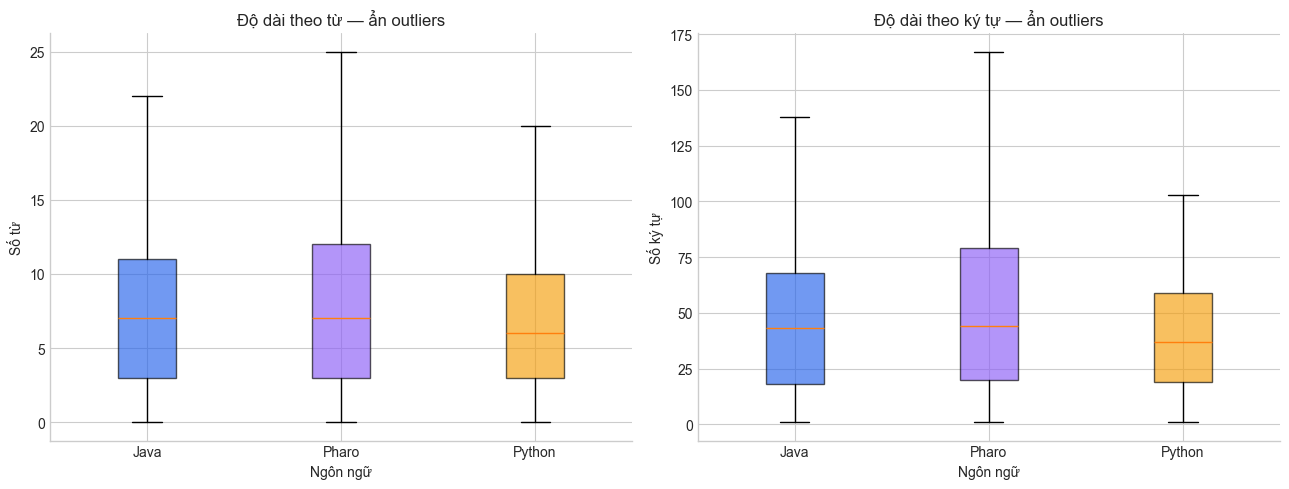

In [9]:
text_parts = []
for lang, df in raw.items():
    part = df[['comment_sentence_id','class','comment_sentence']].drop_duplicates('comment_sentence_id').copy()
    part['Language'] = lang
    part['word_len'] = part.comment_sentence.str.findall(r'\b\w+\b').str.len()
    part['char_len'] = part.comment_sentence.str.len()
    part['normalized_text'] = part.comment_sentence.str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
    part['lowercase'] = part.comment_sentence.eq(part.comment_sentence.str.lower())
    part['ends_punctuation'] = part.comment_sentence.str.contains(r'[.!?]$')
    part['code_token'] = part.comment_sentence.str.contains(r'[_().=]|\b(?:class|def|return|None|True|False)\b', regex=True)
    text_parts.append(part)
texts = pd.concat(text_parts, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
word_data = [texts.loc[texts.Language.eq(lang), 'word_len'] for lang in COLORS]
char_data = [texts.loc[texts.Language.eq(lang), 'char_len'] for lang in COLORS]
bp1 = axes[0].boxplot(word_data, tick_labels=list(COLORS), showfliers=False, patch_artist=True)
bp2 = axes[1].boxplot(char_data, tick_labels=list(COLORS), showfliers=False, patch_artist=True)
for box, color in zip(bp1['boxes'], COLORS.values()): box.set_facecolor(color); box.set_alpha(.65)
for box, color in zip(bp2['boxes'], COLORS.values()): box.set_facecolor(color); box.set_alpha(.65)
finish(axes[0], 'Độ dài theo từ — ẩn outliers', 'Ngôn ngữ', 'Số từ')
finish(axes[1], 'Độ dài theo ký tự — ẩn outliers', 'Ngôn ngữ', 'Số ký tự')
plt.tight_layout()
plt.show()

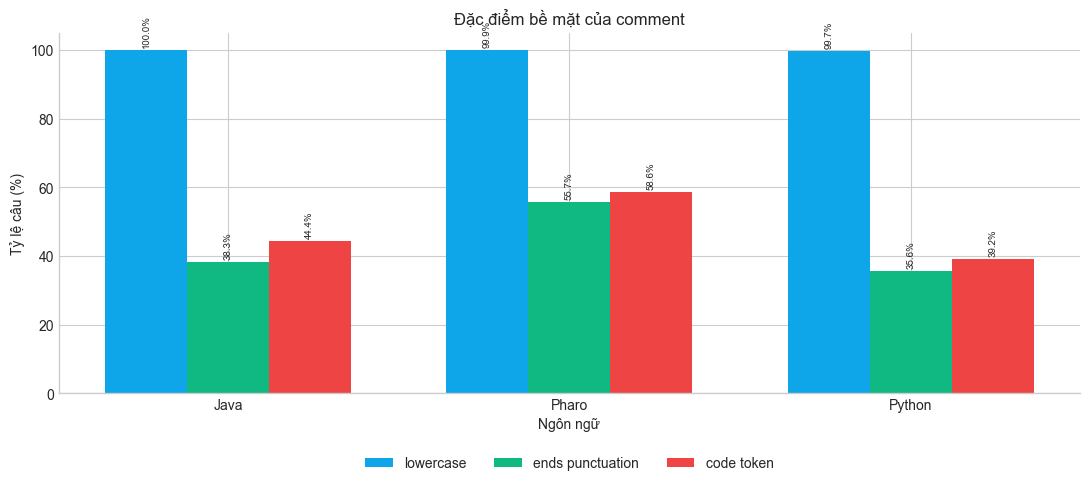

In [10]:
feature_rates = texts.groupby('Language')[['lowercase','ends_punctuation','code_token']].mean() * 100
x = np.arange(len(feature_rates)); width = .24
fig, ax = plt.subplots(figsize=(11, 5))
palette = ['#0EA5E9', '#10B981', '#EF4444']
for j, col in enumerate(feature_rates.columns):
    bars = ax.bar(x + (j-1)*width, feature_rates[col], width, label=col.replace('_',' '), color=palette[j])
    ax.bar_label(bars, labels=[f'{v:.1f}%' for v in feature_rates[col]], fontsize=7, padding=2, rotation=90)
ax.set_xticks(x, feature_rates.index)
finish(ax, 'Đặc điểm bề mặt của comment', 'Ngôn ngữ', 'Tỷ lệ câu (%)')
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(.5, -.14))
plt.tight_layout()
plt.show()

## 7. Token phổ biến

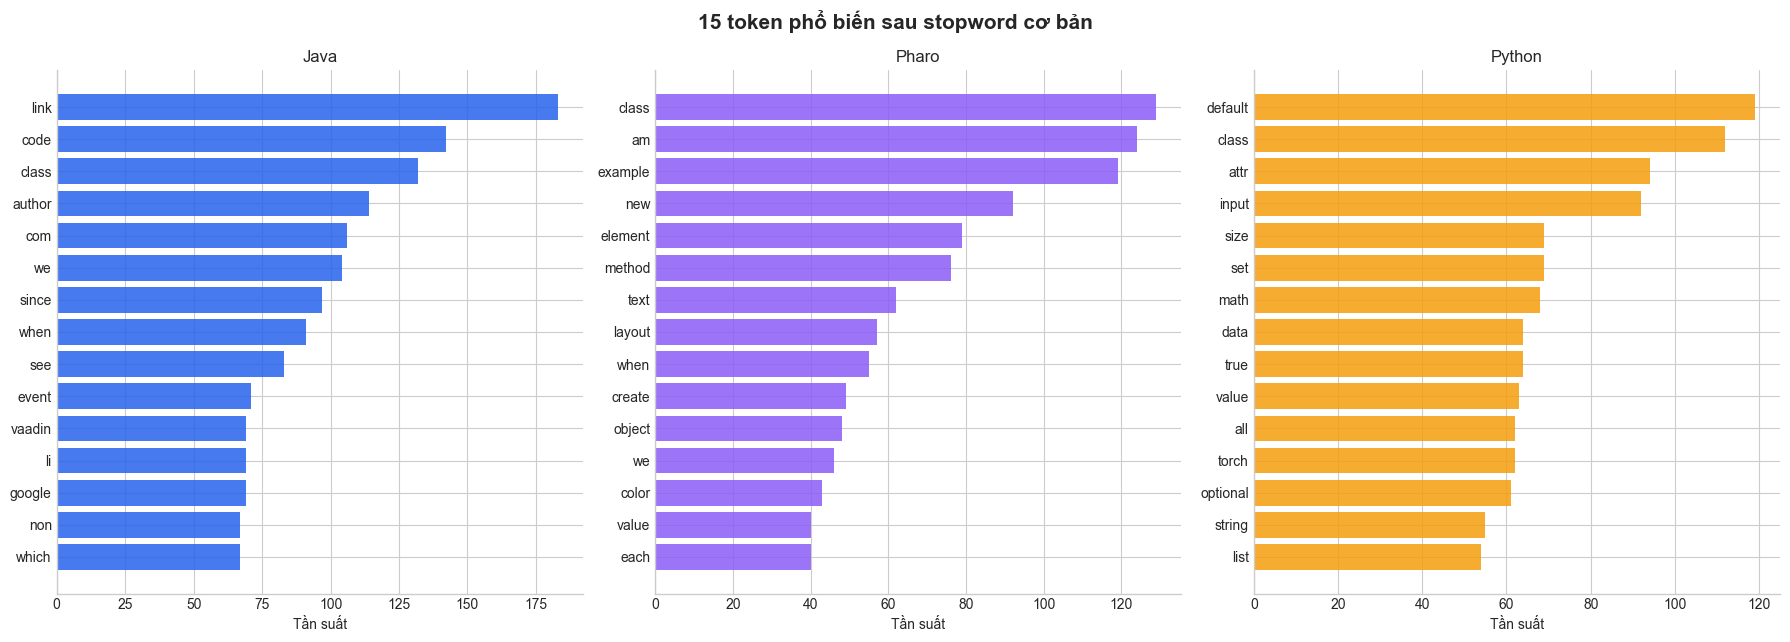

In [11]:
stopwords = {'a','an','the','and','or','of','to','in','for','is','are','be','this','that','with','as','on','by','from','it','if','not','will','can','used','using'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
for ax, lang in zip(axes, COLORS):
    tokens = texts.loc[texts.Language.eq(lang), 'comment_sentence'].str.lower().str.findall(r'[a-zA-Z_][a-zA-Z_0-9]+').explode()
    top = tokens[~tokens.isin(stopwords)].value_counts().head(15).sort_values()
    ax.barh(top.index, top.values, color=COLORS[lang], alpha=.85)
    finish(ax, lang, 'Tần suất', '')
fig.suptitle('15 token phổ biến sau stopword cơ bản', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Class concentration và duplicate

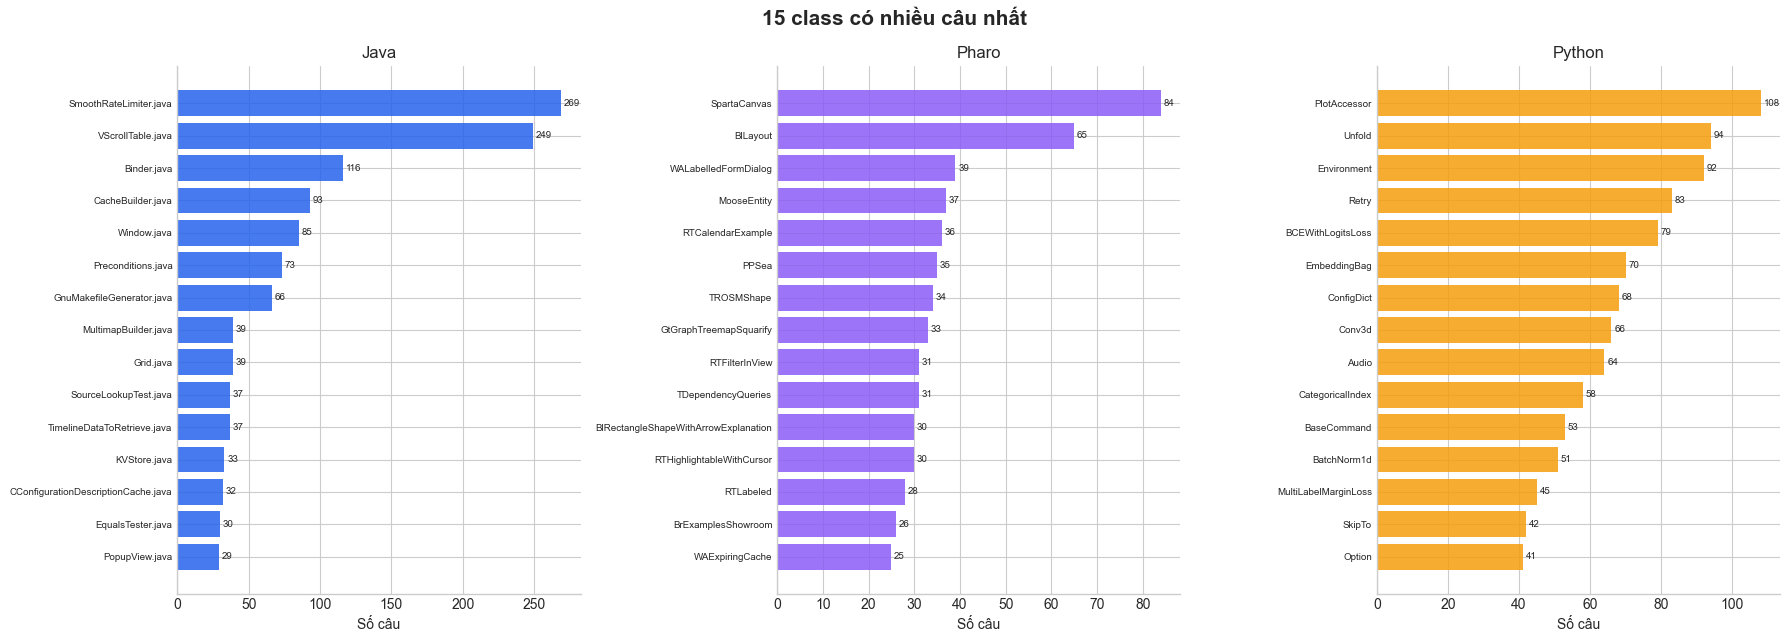

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
for ax, lang in zip(axes, COLORS):
    top = texts.loc[texts.Language.eq(lang), 'class'].value_counts().head(15).sort_values()
    bars = ax.barh(top.index, top.values, color=COLORS[lang], alpha=.85)
    ax.bar_label(bars, fontsize=7, padding=2)
    finish(ax, lang, 'Số câu', '')
    ax.tick_params(axis='y', labelsize=7)
fig.suptitle('15 class có nhiều câu nhất', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

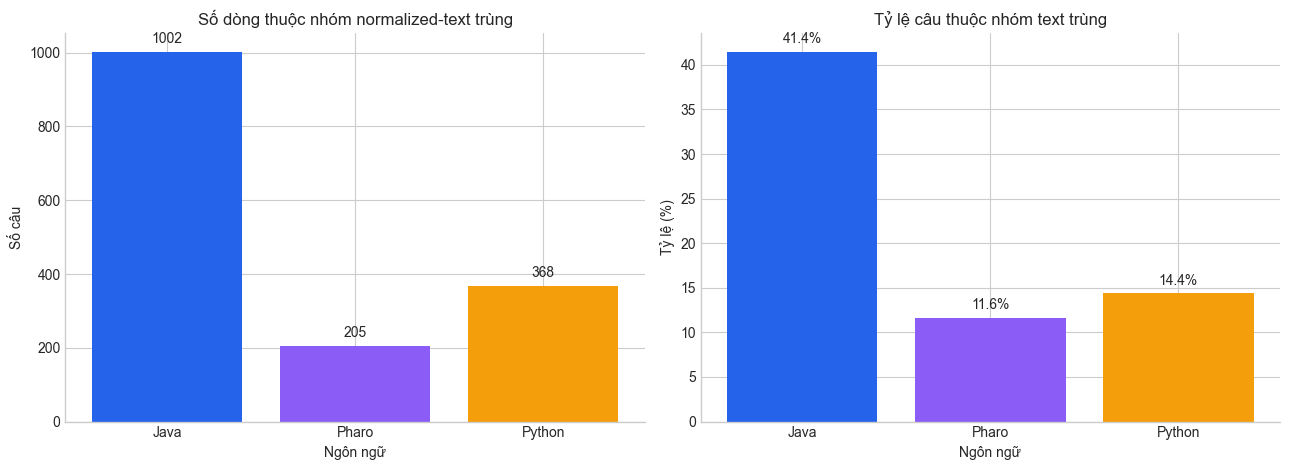

In [13]:
duplicate_counts = texts.groupby('Language').normalized_text.apply(lambda x: x.duplicated(keep=False).sum())
duplicate_rates = 100 * duplicate_counts / texts.groupby('Language').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
bars = axes[0].bar(duplicate_counts.index, duplicate_counts.values, color=[COLORS[x] for x in duplicate_counts.index])
axes[0].bar_label(bars, padding=4)
finish(axes[0], 'Số dòng thuộc nhóm normalized-text trùng', 'Ngôn ngữ', 'Số câu')
bars = axes[1].bar(duplicate_rates.index, duplicate_rates.values, color=[COLORS[x] for x in duplicate_rates.index])
axes[1].bar_label(bars, labels=[f'{x:.1f}%' for x in duplicate_rates], padding=4)
finish(axes[1], 'Tỷ lệ câu thuộc nhóm text trùng', 'Ngôn ngữ', 'Tỷ lệ (%)')
plt.tight_layout()
plt.show()

## 9. Train/test distribution drift

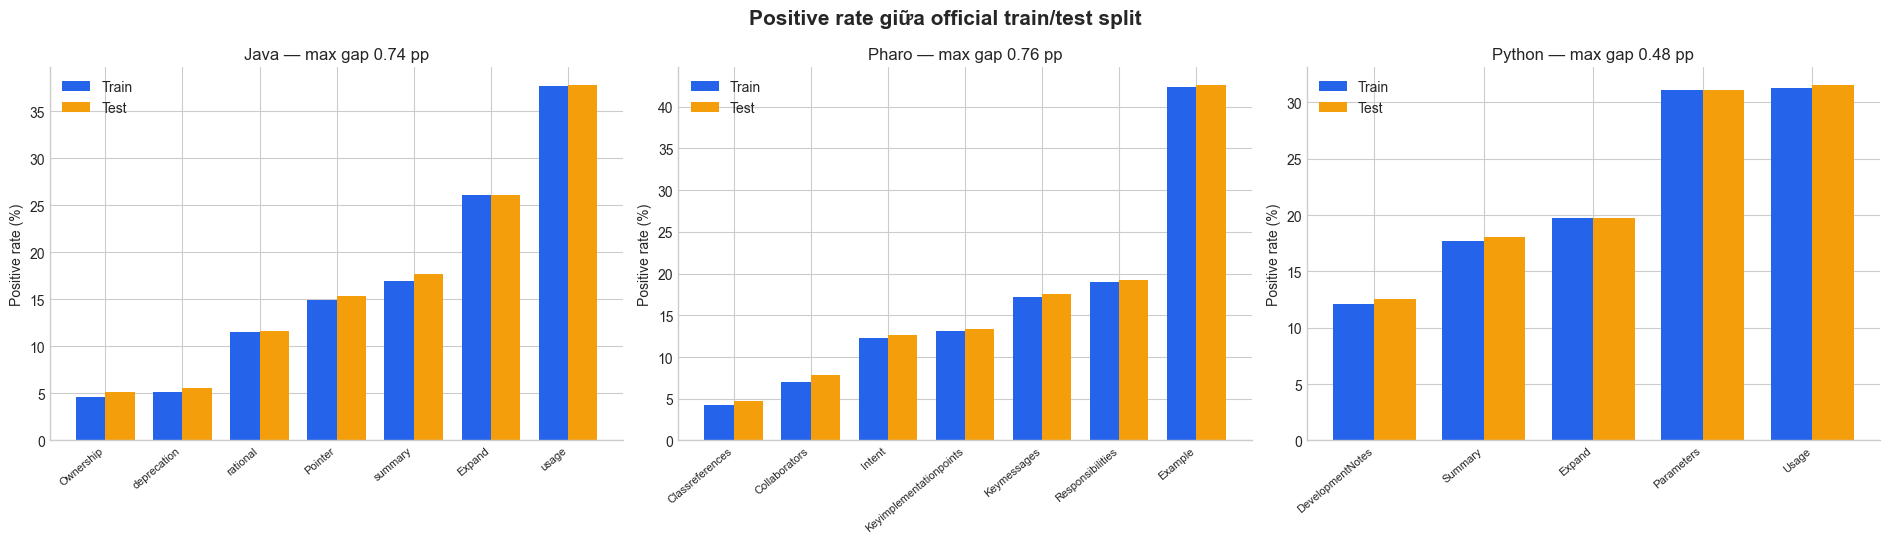

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
max_gaps = {}
for ax, (lang, df) in zip(axes, raw.items()):
    rates = df.groupby(['category','partition']).instance_type.mean().unstack() * 100
    rates.columns = ['Train','Test']
    rates = rates.sort_values('Train')
    max_gaps[lang] = (rates.Train-rates.Test).abs().max()
    x = np.arange(len(rates)); width=.38
    ax.bar(x-width/2, rates.Train, width, label='Train', color='#2563EB')
    ax.bar(x+width/2, rates.Test, width, label='Test', color='#F59E0B')
    ax.set_xticks(x, rates.index, rotation=40, ha='right', fontsize=8)
    finish(ax, f'{lang} — max gap {max_gaps[lang]:.2f} pp', '', 'Positive rate (%)')
    ax.legend()
fig.suptitle('Positive rate giữa official train/test split', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Visual summary dashboard

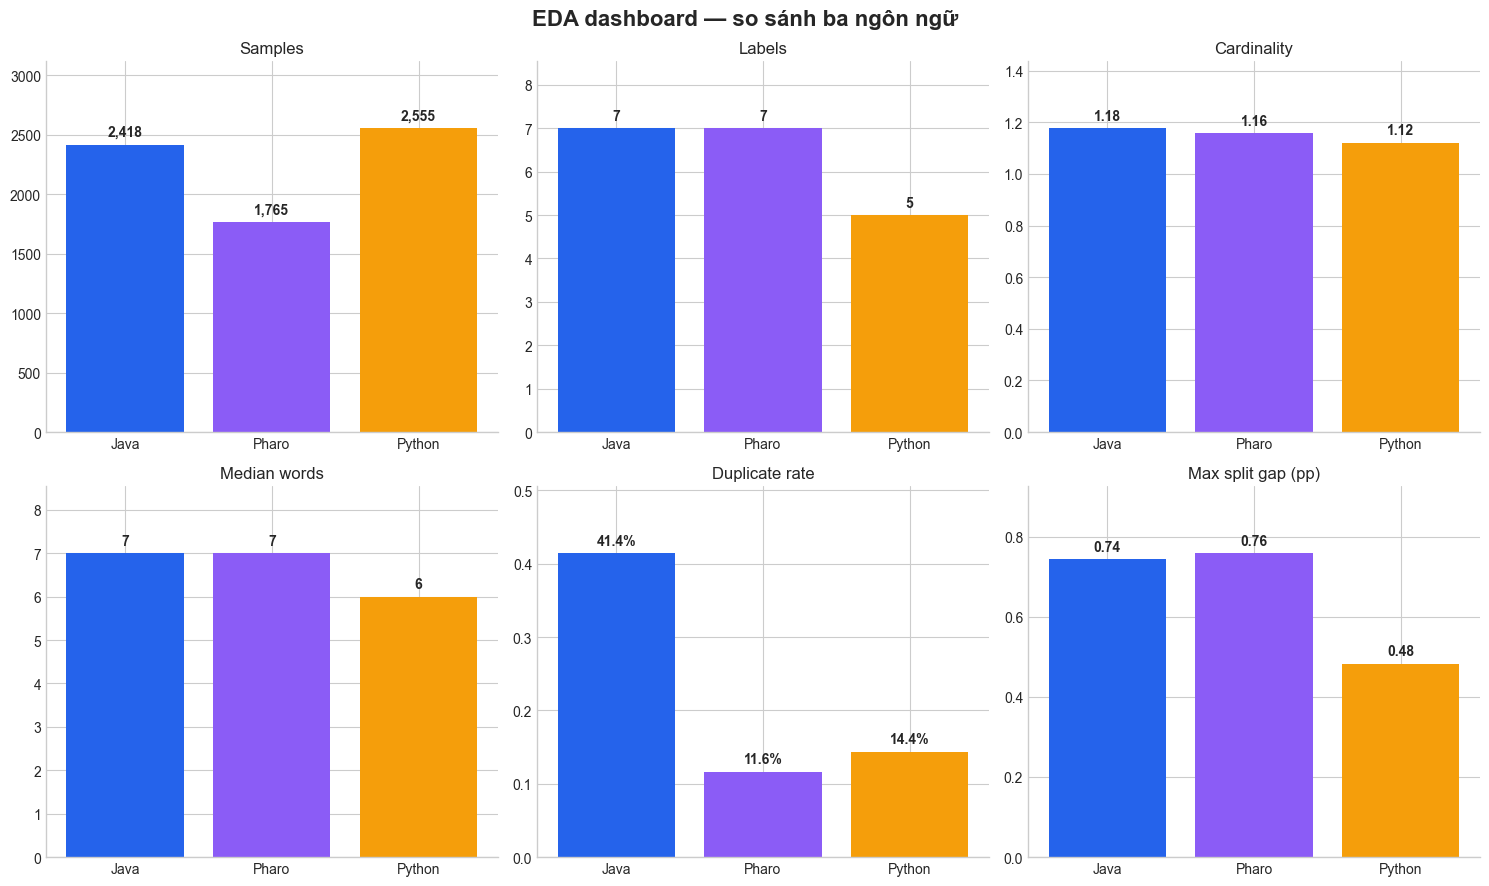

In [15]:
dashboard = pd.DataFrame(index=list(COLORS))
dashboard['Samples'] = sample_counts
dashboard['Labels'] = pd.Series({lang: y.shape[1] for lang, y in wide.items()})
dashboard['Cardinality'] = pd.Series({lang: y.sum(axis=1).mean() for lang, y in wide.items()})
dashboard['Median words'] = texts.groupby('Language').word_len.median()
dashboard['Duplicate rate'] = duplicate_rates / 100
dashboard['Max split gap (pp)'] = pd.Series(max_gaps)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
metrics = [
    ('Samples', '{:,.0f}'), ('Labels', '{:.0f}'), ('Cardinality', '{:.2f}'),
    ('Median words', '{:.0f}'), ('Duplicate rate', '{:.1%}'), ('Max split gap (pp)', '{:.2f}'),
]
for ax, (metric, fmt) in zip(axes.flat, metrics):
    values = dashboard[metric]
    bars = ax.bar(values.index, values.values, color=[COLORS[x] for x in values.index])
    ax.bar_label(bars, labels=[fmt.format(v) for v in values], padding=4, fontweight='bold')
    finish(ax, metric, '', '')
    ax.set_ylim(0, values.max()*1.22 if values.max() else 1)
fig.suptitle('EDA dashboard — so sánh ba ngôn ngữ', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Kết luận trực quan

- Tổng ba ngôn ngữ khớp 6.738 câu; không cộng thêm file Python processed.
- Mức imbalance khác nhau rõ giữa các nhãn và ngôn ngữ, nên cần per-label metrics và macro-F1.
- Một câu có thể mang nhiều nhãn; mô hình joint phải dùng sigmoid/multi-hot, không dùng softmax đơn nhãn.
- Comment ngắn và có nhiều fragment/code token; tránh làm sạch quá mạnh.
- Normalized duplicate và class concentration cho thấy cần group-aware split để hạn chế leakage.
- Positive rate giữa official train/test tương đối sát nhau; vẫn cần kiểm tra text/class drift trong error analysis.